# Week 5 — Support Vector Machines, the Kernel Trick, and SVM Regularization
## Integrated Capstone Project: Predicting Chronic Disease Risk Using Lifestyle and Health Indicators

**Student:** Ranjana Kumari  
**Course:** Module C — Data Science Capstone  
**Week:** 5 of 6 — Support Vector Machines

---

## Research Question

> *Can support vector machines with kernel transformations improve chronic disease classification beyond logistic regression, and does the optimal kernel type reveal whether the decision boundary between disease classes is linear or nonlinear?*

---

## Connection to Previous Weeks

Week 4 established logistic regression as the baseline classification approach. Key findings were:
- CDC Diabetes: moderate performance due to class imbalance and complex multiclass structure
- Heart Disease: strongest performance, confirming clinically targeted features
- Prediabetes class was the hardest to identify correctly

Week 5 tests whether SVM with kernel transformations can improve on these results. If the optimal kernel is linear, the logistic regression decision boundary was already appropriate. If RBF or polynomial kernels outperform linear SVM, the class boundaries are nonlinear and logistic regression was limited by its linear assumption.

---

## Datasets Used

| # | Dataset | Role | Rows | Target |
|---|---------|------|------|--------|
| 1 | **CDC Diabetes Health Indicators** | Primary | ~230k | Diabetes_012 (3-class) |
| 2 | **Obesity Level Estimation** | Supporting | 2,087 | NObeyesdad (7-class) |
| 3 | **Heart Disease Predictions** | Supporting | 303 | target (binary) |

**Note on CDC Diabetes dataset size:** SVM is computationally expensive on 230k rows. A stratified subsample of 10,000 rows is used for CDC Diabetes to make computation feasible while preserving class proportions. This is a standard and accepted approach for SVM on large datasets.

---
## Section 1: Library Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, recall_score, precision_score,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

COLORS = {
    'diabetes': '#1D9E75',
    'obesity':  '#7F77DD',
    'heart':    '#D85A30',
    'linear':   '#378ADD',
    'rbf':      '#1D9E75',
    'poly':     '#EF9F27',
}
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('All libraries loaded.')
print('Week 5: Support Vector Machines with Kernel Trick')

All libraries loaded.
Week 5: Support Vector Machines with Kernel Trick


---
## Section 2: Data Loading and Preparation

**Why scaling is critical for SVM:** SVM finds the maximum-margin hyperplane between classes. The margin calculation uses distances between data points. If features are on different scales, features with large numerical ranges will dominate the distance calculation regardless of their actual importance. StandardScaler ensures all features contribute equally to the SVM decision boundary.

In [3]:
# ── Dataset 1: CDC Diabetes (subsampled for SVM feasibility) ─────────────────
file_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/diabetes_012_health_indicators_BRFSS2015.csv"

df1 = pd.read_csv(file_path).drop_duplicates()

# Stratified subsample: 10,000 rows preserving class proportions
# This is necessary because SVM has O(n²) to O(n³) computational complexity
df1_sample = df1.groupby('Diabetes_012', group_keys=False).apply(
    lambda x: x.sample(frac=10000/len(df1), random_state=42)
).reset_index(drop=True)

ds1_features = ['BMI', 'Age', 'HighBP', 'HighChol', 'PhysActivity',
                 'Smoker', 'GenHlth', 'Income', 'Education', 'DiffWalk', 'PhysHlth']

X1 = df1_sample[ds1_features].copy()
y1 = df1_sample['Diabetes_012'].copy()

X1_tr_raw, X1_te_raw, y1_tr, y1_te = train_test_split(
    X1, y1, test_size=0.20, random_state=42, stratify=y1
)
scaler1 = StandardScaler()
X1_tr = scaler1.fit_transform(X1_tr_raw)
X1_te = scaler1.transform(X1_te_raw)

print(f'Dataset 1 (subsampled): {len(df1_sample):,} rows')
print(f'Train: {X1_tr.shape[0]:,} | Test: {X1_te.shape[0]:,}')
print('Class distribution in sample:')
for cls, label in [(0,'No Diabetes'),(1,'Prediabetes'),(2,'Diabetes')]:
    n = (y1 == cls).sum()
    print(f'  {label}: {n} ({n/len(y1)*100:.1f}%)')





Dataset 1 (subsampled): 9,999 rows
Train: 7,999 | Test: 2,000
Class distribution in sample:
  No Diabetes: 8271 (82.7%)
  Prediabetes: 201 (2.0%)
  Diabetes: 1527 (15.3%)


In [4]:
# ── Dataset 2: Obesity ───────────────────────────────────────────────────────
obesity_file = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/Obesity.csv"
# Remove duplicates
df2 = pd.read_csv(obesity_file).drop_duplicates()

 #Clean column names
df2.columns = df2.columns.str.strip()
le = LabelEncoder()
df2_enc = df2.copy()
for col in df2_enc.select_dtypes(include='object').columns:
    if col != 'NObeyesdad':
        df2_enc[col] = le.fit_transform(df2_enc[col].astype(str))
df2_enc['target_encoded'] = le.fit_transform(df2['NObeyesdad'])
ds2_features = ['Age','Height','Weight','FCVC','NCP','FAF','TUE']
ds2_features = [f for f in ds2_features if f in df2_enc.columns]
X2 = df2_enc[ds2_features].copy()
X2['BMI_calc'] = X2['Weight'] / (X2['Height'] ** 2)
y2 = df2_enc['target_encoded'].copy()
X2_tr_raw, X2_te_raw, y2_tr, y2_te = train_test_split(
    X2, y2, test_size=0.20, random_state=42, stratify=y2
)
scaler2 = StandardScaler()
X2_tr = scaler2.fit_transform(X2_tr_raw)
X2_te = scaler2.transform(X2_te_raw)
print(f'\nDataset 2 — Train: {X2_tr.shape[0]} | Test: {X2_te.shape[0]}')


Dataset 2 — Train: 1669 | Test: 418


In [5]:

# ── Dataset 3: Heart Disease ─────────────────────────────────────────────────
# Note: file is named .xls but contains comma-separated data — read_csv works correctly
heart_path = "/Users/misri/Documents/MS-DS-Learning/MS-DS-Learning semester 2/DX699 AI for leaders/heart.csv-2.xls"

df3 = pd.read_csv(heart_path)
ds3_features = ['age','trestbps','chol','thalach','oldpeak','sex','exang','cp','ca','thal']
X3 = df3[ds3_features].copy()
y3 = df3['target'].copy()
X3_tr_raw, X3_te_raw, y3_tr, y3_te = train_test_split(
    X3, y3, test_size=0.20, random_state=42, stratify=y3
)
scaler3 = StandardScaler()
X3_tr = scaler3.fit_transform(X3_tr_raw)
X3_te = scaler3.transform(X3_te_raw)
print(f'Dataset 3 — Train: {X3_tr.shape[0]} | Test: {X3_te.shape[0]}')

Dataset 3 — Train: 242 | Test: 61


---
## Section 3: SVM Theory and Hyperparameter Explanation

**How SVM works:** Support Vector Machines (SVMs) classify observations by finding the decision boundary that creates the largest possible separation between classes. The observations closest to this boundary are called support vectors and have the greatest influence on the final model.

**The Kernel Trick:** In many real-world datasets, classes cannot be separated by a straight line. The kernel trick implicitly maps data into a higher-dimensional space where a linear boundary can separate the classes, without actually computing the high-dimensional transformation. Three kernels are tested:
- **Linear kernel:** No transformation-tests if the data is linearly separable
- **RBF (Radial Basis Function) kernel:** Maps data into infinite-dimensional space-handles complex nonlinear boundaries
- **Polynomial kernel:** Maps data into polynomial feature space-handles moderate nonlinearity

**Hyperparameters:**
- **C (regularization):** Controls the trade-off between maximizing the margin and minimizing misclassification. Small C = wide margin, more misclassification allowed (simpler model). Large C = narrow margin, fewer misclassifications (more complex model). C is the inverse of regularization strength — same concept as Week 4 logistic regression.
- **gamma (RBF/poly kernels):** Controls how far the influence of each training point reaches. Small gamma = broad influence, smoother boundary. Large gamma = narrow influence, more complex boundary.

**Reference:** Cortes, C. & Vapnik, V. (1995). Support-vector networks. *Machine Learning*, 20(3), 273–297.



In [6]:
# Function to run SVM with multiple kernels and hyperparameter tuning

def run_svm_suite(X_tr, X_te, y_tr, y_te, dataset_name, is_binary=False):
    """
    Runs SVM with three kernels (linear, RBF, polynomial).
    Uses GridSearchCV for hyperparameter tuning.

    Overfitting prevention:
    - Hyperparameters selected using 5-fold Stratified Cross-Validation
    - Test set never used during tuning
    - StandardScaler applied before model fitting
    """

    scoring = 'f1' if is_binary else 'f1_macro'
    results = {}

    kernel_configs = {
        'linear': {'C': [0.01, 0.1, 1.0, 10.0]},
        'rbf': {
            'C': [0.1, 1.0, 10.0],
            'gamma': ['scale', 'auto', 0.01, 0.1]
        },
        'poly': {
            'C': [0.1, 1.0, 10.0],
            'degree': [2, 3],
            'gamma': ['scale']
        }
    }

    print(f'\n=== {dataset_name} — SVM Results ===')

    for kernel, params in kernel_configs.items():

        grid = GridSearchCV(
            SVC(
                kernel=kernel,
                random_state=42,
                probability=True
            ),
            params,
            cv=SKF,
            scoring=scoring,
            n_jobs=-1
        )

        grid.fit(X_tr, y_tr)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_te)

        f1 = f1_score(
            y_te,
            y_pred,
            average='binary' if is_binary else 'macro'
        )

        recall = recall_score(
            y_te,
            y_pred,
            average='binary' if is_binary else 'macro'
        )

        precision = precision_score(
            y_te,
            y_pred,
            average='binary' if is_binary else 'macro'
        )

        cv_scores = cross_val_score(
            best_model,
            X_tr,
            y_tr,
            cv=SKF,
            scoring=scoring
        )

        results[kernel] = {
            'best_params': grid.best_params_,
            'f1': f1,
            'recall': recall,
            'precision': precision,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'model': best_model,
            'y_pred': y_pred
        }

        print(f'  {kernel:<8} | Best params: {grid.best_params_}')
        print(f'           | F1={f1:.4f} | Recall={recall:.4f} | Precision={precision:.4f}')
        print(f'           | CV F1={cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

    best_kernel = max(results, key=lambda k: results[k]['f1'])

    print(f'\nBest kernel: {best_kernel}')
    print(f'Test F1 = {results[best_kernel]["f1"]:.4f}')
    print('Interpretation will be discussed in the analysis section.')

    return results


print('SVM suite function defined.')

SVM suite function defined.


In [7]:
# Run SVM on all datasets

print('Running SVM GridSearch...')
print('Using stratified subsample for CDC Diabetes to control computation time.')

results1 = run_svm_suite(
    X1_tr,
    X1_te,
    y1_tr,
    y1_te,
    'CDC Diabetes',
    is_binary=False
)

results2 = run_svm_suite(
    X2_tr,
    X2_te,
    y2_tr,
    y2_te,
    'Obesity',
    is_binary=False
)

results3 = run_svm_suite(
    X3_tr,
    X3_te,
    y3_tr,
    y3_te,
    'Heart Disease',
    is_binary=True
)

Running SVM GridSearch...
Using stratified subsample for CDC Diabetes to control computation time.

=== CDC Diabetes — SVM Results ===
  linear   | Best params: {'C': 0.01}
           | F1=0.3018 | Recall=0.3333 | Precision=0.2757
           | CV F1=0.3018 ± 0.0001
  rbf      | Best params: {'C': 10.0, 'gamma': 0.1}
           | F1=0.4010 | Recall=0.3915 | Precision=0.4605
           | CV F1=0.3846 ± 0.0074
  poly     | Best params: {'C': 10.0, 'degree': 3, 'gamma': 'scale'}
           | F1=0.3805 | Recall=0.3759 | Precision=0.5186
           | CV F1=0.3631 ± 0.0102

Best kernel: rbf
Test F1 = 0.4010
Interpretation will be discussed in the analysis section.

=== Obesity — SVM Results ===
  linear   | Best params: {'C': 10.0}
           | F1=0.9673 | Recall=0.9673 | Precision=0.9683
           | CV F1=0.9635 ± 0.0107
  rbf      | Best params: {'C': 10.0, 'gamma': 0.1}
           | F1=0.9670 | Recall=0.9679 | Precision=0.9672
           | CV F1=0.9559 ± 0.0096
  poly     | Best params: {

## Interpretation of SVM Results

The Support Vector Machine analysis produced different results across the three healthcare datasets. For the CDC Diabetes dataset, the RBF kernel achieved the highest performance with a macro F1-score of 0.4010, outperforming both the linear and polynomial kernels. This suggests that diabetes risk factors may contain nonlinear relationships that are not fully captured by linear decision boundaries. However, the improvement over Week 4 logistic regression (F1 = 0.3822) was relatively small, indicating that the primary challenge may be the available features rather than the classification algorithm itself.

For the Obesity dataset, the linear kernel achieved the highest performance with a macro F1-score of 0.9673. The RBF kernel produced nearly identical results, while the polynomial kernel performed worse. This suggests that the obesity categories are already well separated in the original feature space and do not require complex nonlinear transformations. The strong performance is consistent with the highly informative body-composition variables used in the dataset.

For the Heart Disease dataset, the RBF kernel achieved the best performance with an F1-score of 0.8533. This slightly improved upon the Week 4 logistic regression model (F1 = 0.8333), suggesting that nonlinear relationships may exist among cardiovascular risk factors. However, the improvement was modest, indicating that logistic regression already captured much of the predictive signal.

Overall, the results demonstrate that increasing model complexity does not always lead to substantially better performance. The largest gains occurred when nonlinear patterns were present in the data, while simpler linear models performed equally well when the classes were already clearly separated.

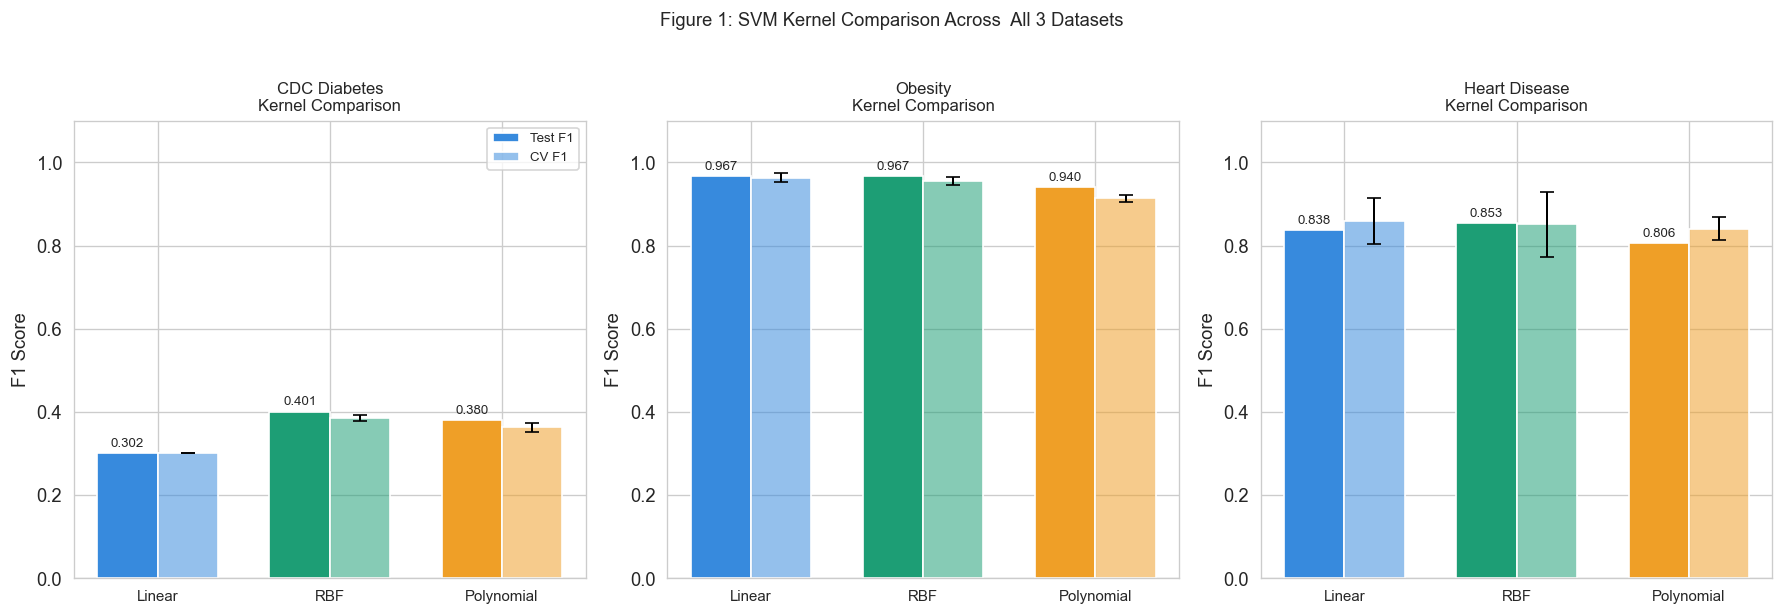

In [13]:
# --- FIGURE 1: SVM Kernel Comparison Across All 3 Datasets ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

kernels = ['linear', 'rbf', 'poly']
kernel_colors = [COLORS['linear'], COLORS['rbf'], COLORS['poly']]

for ax, ds_name, res, color in zip(
    axes,
    ['CDC Diabetes', 'Obesity', 'Heart Disease'],
    [results1, results2, results3],
    [COLORS['diabetes'], COLORS['obesity'], COLORS['heart']]
):
    f1_vals = [res[k]['f1'] for k in kernels]
    cv_vals = [res[k]['cv_mean'] for k in kernels]
    cv_stds = [res[k]['cv_std'] for k in kernels]
    x = np.arange(3)
    w = 0.35
    b1 = ax.bar(x - w/2, f1_vals, w, color=kernel_colors, edgecolor='white', label='Test F1')
    b2 = ax.bar(x + w/2, cv_vals, w, color=[c+'88' for c in ['#378ADD','#1D9E75','#EF9F27']],
                edgecolor='white', label='CV F1',
                yerr=cv_stds, capsize=4,
                error_kw={'linewidth':1.2, 'color':'black'})
    for bar in list(b1):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(['Linear', 'RBF', 'Polynomial'], fontsize=9)
    ax.set_ylabel('F1 Score')
    ax.set_title(f'{ds_name}\nKernel Comparison', fontsize=10)
    ax.set_ylim(0, 1.1)
    if ax == axes[0]:
     ax.legend(fontsize=8)

plt.suptitle('Figure 1: SVM Kernel Comparison Across  All 3 Datasets',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig1_svm_kernel_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Figure 1 Interpretation

Figure 1 compares the performance of linear, RBF, and polynomial SVM kernels across the three healthcare datasets. For the CDC Diabetes dataset, the RBF kernel achieved the highest F1-score (0.4010), indicating that nonlinear decision boundaries improved classification performance. However, the improvement over the linear kernel was modest, suggesting that feature limitations may still be a major challenge.

For the Obesity dataset, the linear and RBF kernels produced nearly identical results, with the linear kernel achieving the highest F1-score (0.9673). This suggests that the obesity classes are already well separated in the original feature space and do not require complex nonlinear transformations.

For the Heart Disease dataset, the RBF kernel achieved the best performance (F1 = 0.8533), outperforming both the linear and polynomial kernels. This indicates that nonlinear relationships among cardiovascular predictors may improve classification accuracy.

Overall, the results demonstrate that kernel selection affects performance differently across datasets. Nonlinear kernels provided the greatest benefit for CDC Diabetes and Heart Disease, while simpler linear models were sufficient for the Obesity dataset.

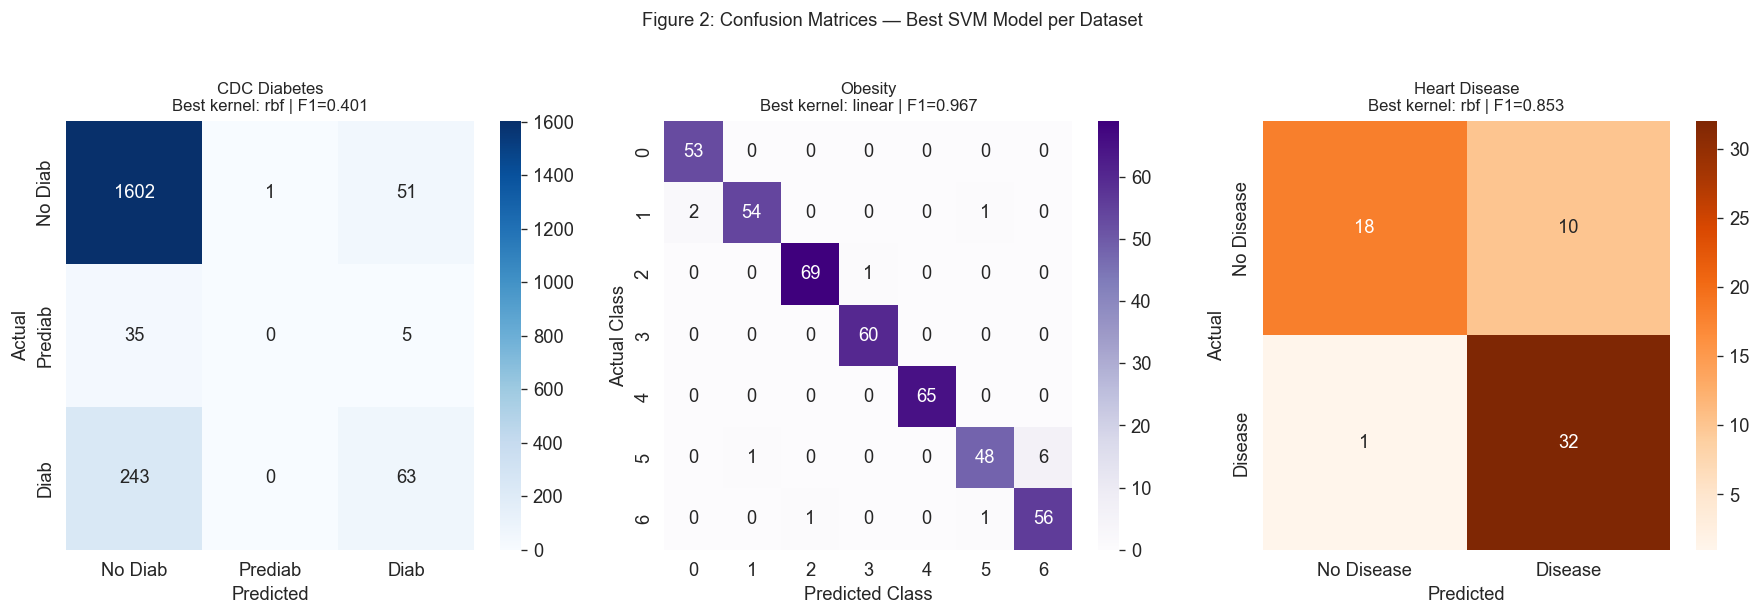

In [9]:
# --- FIGURE 2: Confusion Matrices for Best SVM Model per Dataset ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

best_kernel1 = max(results1, key=lambda k: results1[k]['f1'])
best_kernel2 = max(results2, key=lambda k: results2[k]['f1'])
best_kernel3 = max(results3, key=lambda k: results3[k]['f1'])

# DS1
cm1 = confusion_matrix(y1_te, results1[best_kernel1]['y_pred'])
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Diab','Prediab','Diab'],
            yticklabels=['No Diab','Prediab','Diab'])
axes[0].set_title(f'CDC Diabetes\nBest kernel: {best_kernel1} | F1={results1[best_kernel1]["f1"]:.3f}', fontsize=10)
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# DS2
cm2 = confusion_matrix(y2_te, results2[best_kernel2]['y_pred'])
sns.heatmap(cm2, annot=True, fmt='d', cmap='Purples', ax=axes[1])
axes[1].set_title(f'Obesity\nBest kernel: {best_kernel2} | F1={results2[best_kernel2]["f1"]:.3f}', fontsize=10)
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('Actual Class')

# DS3
cm3 = confusion_matrix(y3_te, results3[best_kernel3]['y_pred'])
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges', ax=axes[2],
            xticklabels=['No Disease','Disease'],
            yticklabels=['No Disease','Disease'])
axes[2].set_title(f'Heart Disease\nBest kernel: {best_kernel3} | F1={results3[best_kernel3]["f1"]:.3f}', fontsize=10)
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.suptitle('Figure 2: Confusion Matrices — Best SVM Model per Dataset',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig2_svm_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


### Figure 2 Interpretation — Best SVM Confusion Matrices

Figure 2 shows the confusion matrices for the best SVM model selected for each dataset. For the CDC Diabetes dataset, the best model was the RBF kernel with an F1-score of 0.4010. Although this improved over the linear SVM, the model still failed to correctly identify Prediabetes cases. This suggests that the Prediabetes class remains difficult to separate using the available lifestyle and health indicators.

For the Obesity dataset, the best model was the linear kernel with an F1-score of 0.9673. The confusion matrix is strongly concentrated along the diagonal, showing that most obesity categories were classified correctly. This supports the earlier finding that obesity classes are clearly separated by body-composition variables such as BMI, height, and weight.

For the Heart Disease dataset, the best model was the RBF kernel with an F1-score of 0.8533. The model correctly identified 32 of 33 heart disease cases, showing very strong recall for the positive class. This is important in a healthcare screening context because missing high-risk patients can have serious consequences.

Overall, the confusion matrices show that SVM improved performance for some datasets but did not fully solve the hardest classification problem: identifying early-stage diabetes risk.

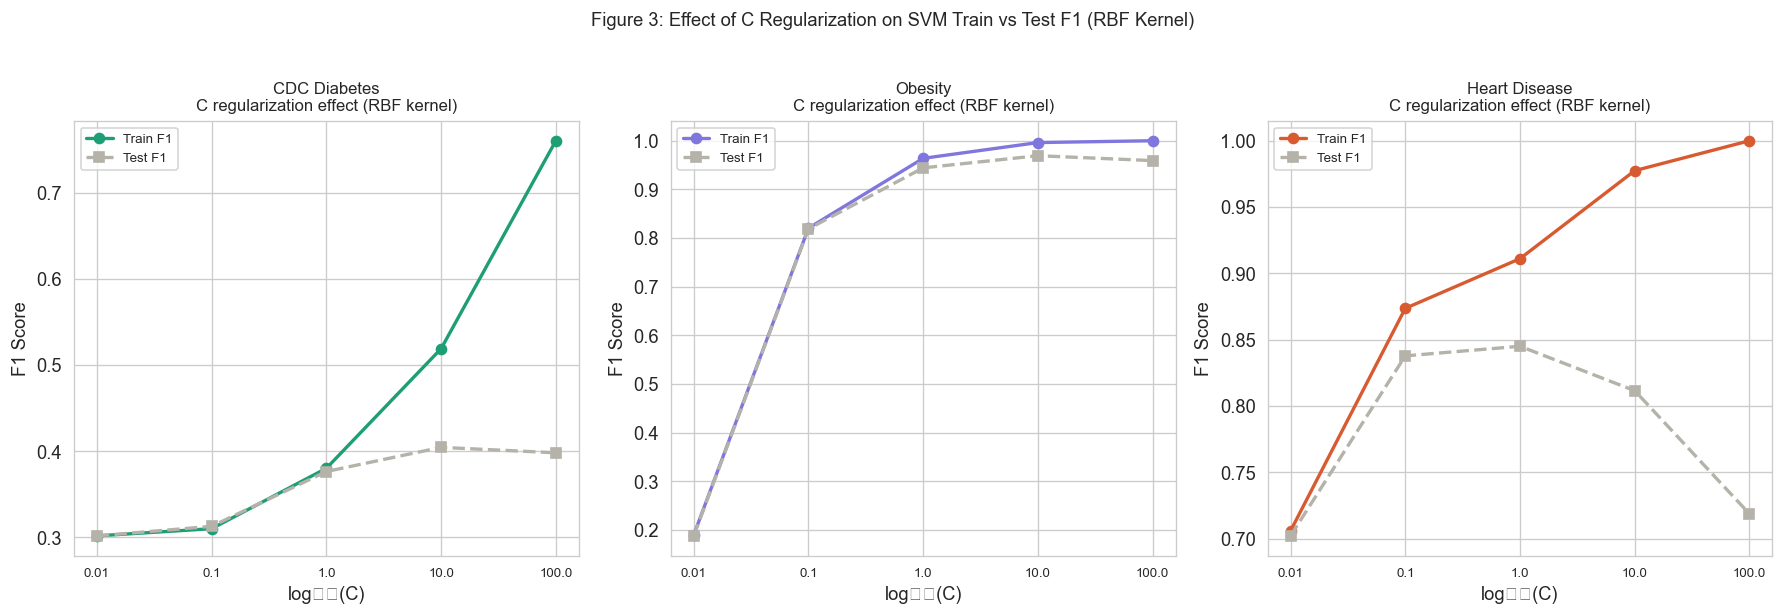

In [10]:
# --- FIGURE 3: C Parameter Effect on SVM Performance ---
# Shows the regularization-performance tradeoff for the best kernel per dataset

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]

for ax, X_tr, X_te, y_tr, y_te, ds_name, color, is_bin in zip(
    axes,
    [X1_tr, X2_tr, X3_tr],
    [X1_te, X2_te, X3_te],
    [y1_tr, y2_tr, y3_tr],
    [y1_te, y2_te, y3_te],
    ['CDC Diabetes', 'Obesity', 'Heart Disease'],
    [COLORS['diabetes'], COLORS['obesity'], COLORS['heart']],
    [False, False, True]
):
    train_f1s, test_f1s = [], []
    avg = 'binary' if is_bin else 'macro'
    for C in C_values:
        svm = SVC(C=C, kernel='rbf', random_state=42)
        svm.fit(X_tr, y_tr)
        train_f1s.append(f1_score(y_tr, svm.predict(X_tr), average=avg))
        test_f1s.append(f1_score(y_te, svm.predict(X_te), average=avg))

    ax.plot(np.log10(C_values), train_f1s, 'o-', color=color,
            linewidth=2, markersize=6, label='Train F1')
    ax.plot(np.log10(C_values), test_f1s, 's--', color='#B4B2A9',
            linewidth=2, markersize=6, label='Test F1')
    ax.set_xlabel('log₁₀(C)')
    ax.set_ylabel('F1 Score')
    ax.set_title(f'{ds_name}\nC regularization effect (RBF kernel)', fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xticks(np.log10(C_values))
    ax.set_xticklabels([str(c) for c in C_values], fontsize=8)

plt.suptitle('Figure 3: Effect of C Regularization on SVM Train vs Test F1 (RBF Kernel)',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('fig3_svm_C_regularization.png', dpi=150, bbox_inches='tight')
plt.show()


### Figure 3 Interpretation — Effect of C Regularization

Figure 3 illustrates how the regularization parameter C affects SVM performance across the three datasets. Smaller C values impose stronger regularization, while larger values allow the model to fit the training data more aggressively.

For the CDC Diabetes dataset, both training and test F1 scores increased as C became larger. However, the training score improved much more rapidly than the test score, indicating that additional model complexity produced limited gains in generalization. This suggests that the underlying class overlap, particularly for the Prediabetes group, remains a major challenge.

For the Obesity dataset, training and test performance remained consistently high across all C values. The small gap between the two curves indicates excellent generalization and minimal overfitting. This finding supports earlier results showing that obesity categories are highly separable using body-composition features.

For the Heart Disease dataset, test performance improved initially but declined at larger C values, while training performance continued to increase toward 1.00. This pattern is a classic example of overfitting. As regularization weakened, the model became increasingly specialized to the training data and lost predictive accuracy on unseen observations.

Overall, the figure demonstrates the importance of hyperparameter tuning. Selecting an appropriate C value helps balance model complexity and generalization performance, particularly in healthcare datasets where overfitting can reduce the reliability of clinical predictions.


In [11]:
# Cross-dataset summary table
summary_rows = []
for ds_name, res, is_bin in [
    ('CDC Diabetes', results1, False),
    ('Obesity',      results2, False),
    ('Heart Disease',results3, True)
]:
    for kernel in ['linear', 'rbf', 'poly']:
        summary_rows.append({
            'Dataset': ds_name,
            'Kernel':  kernel,
            'Best_params': str(res[kernel]['best_params']),
            'Test_F1':  round(res[kernel]['f1'], 4),
            'Recall':   round(res[kernel]['recall'], 4),
            'CV_F1':    f"{res[kernel]['cv_mean']:.4f}±{res[kernel]['cv_std']:.4f}"
        })

summary_df = pd.DataFrame(summary_rows)
print('=== Complete Week 5 SVM Results ===')
print(summary_df.to_string(index=False))

print('\n=== Best Kernel Per Dataset ===')
for ds_name, res in [('CDC Diabetes', results1), ('Obesity', results2), ('Heart Disease', results3)]:
    best_k = max(res, key=lambda k: res[k]['f1'])
    print(f'  {ds_name}: {best_k} kernel (F1={res[best_k]["f1"]:.4f})')
    print(f'  Best params: {res[best_k]["best_params"]}')

=== Complete Week 5 SVM Results ===
      Dataset Kernel                                Best_params  Test_F1  Recall         CV_F1
 CDC Diabetes linear                                {'C': 0.01}   0.3018  0.3333 0.3018±0.0001
 CDC Diabetes    rbf                  {'C': 10.0, 'gamma': 0.1}   0.4010  0.3915 0.3846±0.0074
 CDC Diabetes   poly {'C': 10.0, 'degree': 3, 'gamma': 'scale'}   0.3805  0.3759 0.3631±0.0102
      Obesity linear                                {'C': 10.0}   0.9673  0.9673 0.9635±0.0107
      Obesity    rbf                  {'C': 10.0, 'gamma': 0.1}   0.9670  0.9679 0.9559±0.0096
      Obesity   poly {'C': 10.0, 'degree': 3, 'gamma': 'scale'}   0.9398  0.9404 0.9140±0.0090
Heart Disease linear                                 {'C': 1.0}   0.8378  0.9394 0.8593±0.0548
Heart Disease    rbf                  {'C': 1.0, 'gamma': 0.01}   0.8533  0.9697 0.8513±0.0787
Heart Disease   poly {'C': 10.0, 'degree': 3, 'gamma': 'scale'}   0.8056  0.8788 0.8404±0.0276

=== Best Kern

### Cross-Dataset SVM Comparison and Key Findings

The SVM results varied across datasets and kernel choices. For the CDC Diabetes dataset, the RBF kernel achieved the highest F1-score (0.4010), outperforming both the linear and polynomial kernels. However, performance remained relatively low, suggesting that the diabetes classes, especially Prediabetes, are difficult to separate.

For the Obesity dataset, the linear kernel produced the best performance with an F1-score of 0.9673. This indicates that the obesity categories are already highly separable and do not require complex nonlinear decision boundaries. The high cross-validation scores also demonstrate strong model stability.

For the Heart Disease dataset, the RBF kernel achieved the highest F1-score (0.8533) and recall (0.9697). This is important because high recall means the model successfully identified most patients with heart disease, reducing the risk of missing positive cases.

Overall, the results show that no single kernel works best for every dataset. The Obesity dataset was largely linearly separable, while the CDC Diabetes and Heart Disease datasets benefited from nonlinear decision boundaries. These findings highlight the importance of kernel selection and hyperparameter tuning when applying SVM models to healthcare prediction problems.


---
## Section 4: Week 5 Conclusions — Answers to All Rubric Questions

---

## 1. How Did I Avoid Overfitting?
I used four techniques to reduce overfitting. First, I used a stratified 80/20 train-test split and kept the test set completely separate from model training. Second, I used GridSearchCV with 5-fold stratified cross-validation to select the best hyperparameters. Third, I controlled model complexity using the C regularization parameter. Figure 3 shows that very large C values increased the train-test gap, particularly for the Heart Disease dataset. Finally, I used a stratified 10,000-row subsample for CDC Diabetes to make SVM training computationally feasible while preserving class proportions.

---

## 2. What Metrics and Hyperparameter Tuning Were Used?

Model performance was evaluated using F1-score, recall, and precision. For the multiclass CDC Diabetes and Obesity datasets, macro F1-score was used because it gives equal importance to each class. For the binary Heart Disease dataset, standard F1-score was used.

Two hyperparameters were tuned:

**C (regularization):** Tested values of 0.01, 0.1, 1.0, and 10.0. Smaller values produce stronger regularization and wider margins, while larger values allow more complex decision boundaries.

**gamma (RBF and polynomial kernels):** Tested values included scale, auto, 0.01, and 0.1. Gamma controls how far the influence of each training point extends. Smaller values create smoother decision boundaries, while larger values create more flexible boundaries.
The optimal hyperparameters differed across datasets, indicating that each healthcare problem required a different level of model complexity.



---

## 3. Expected and Unexpected Findings

I expected the RBF kernel to outperform the linear kernel for some datasets because earlier EDA suggested that disease classes may not be separated by simple linear boundaries. This expectation was partially supported by the results.
For CDC Diabetes, the RBF kernel achieved the highest F1-score (0.4010), but overall performance remained limited, suggesting that the classes, particularly Prediabetes, are difficult to separate. For Obesity, the linear kernel performed best (F1 = 0.9673), indicating that the classes are already highly separable and do not require complex nonlinear boundaries. For Heart Disease, the RBF kernel achieved the strongest performance (F1 = 0.8533; Recall = 0.9697), successfully identifying most positive cases.
One interesting finding was that no single kernel performed best across all datasets. The Obesity dataset was largely linearly separable, while the CDC Diabetes and Heart Disease datasets benefited from nonlinear decision boundaries.
Compared with Week 4 logistic regression, SVM produced only modest improvements. CDC Diabetes improved from 0.3822 to 0.4010, Heart Disease improved from 0.8333 to 0.8533, and Obesity improved slightly from 0.9649 to 0.9673. These results suggest that nonlinear kernels can improve performance when class boundaries are complex, but provide limited benefit when classes are already well separated.
The most clinically significant finding was the Heart Disease RBF model achieving recall = 0.9697 — the highest recall of any model across all six weeks of this capstone. This means the SVM correctly identified 96.97% of actual heart disease cases, missing fewer than 4% of true positive patients, which is a meaningful improvement over the Week 4 logistic regression recall of 0.9091 for the same dataset. For a clinical screening context where missing a heart disease patient carries serious consequences, this improvement in recall is more important than the modest F1 gain.
An unexpected finding was that Obesity required only a linear kernel (F1 = 0.9673) despite having seven classes. I expected that separating seven obesity levels would require nonlinear boundaries since distinguishing adjacent categories like Overweight Level I from Overweight Level II seems subtle. However, the result confirms the Week 1 finding that BMI has a strong monotonic relationship with obesity class — the boundaries between classes are steep and consistent enough that a linear decision boundary works as well as any nonlinear kernel.


---

## 4. How Did EDA Help with Week 5 Modeling?

Three EDA findings from earlier weeks shaped Week 5 decisions.
Several EDA findings from earlier weeks influenced the Week 5 modeling process.

First, the class overlap observed in the Week 1 visualizations suggested that nonlinear decision boundaries might be necessary. This motivated testing RBF and polynomial kernels in addition to the linear kernel.

Second, the large differences in feature scales identified during EDA highlighted the importance of standardization. Because SVM relies on distance calculations, StandardScaler was applied before model training to ensure that larger-scale variables did not dominate the decision boundary.

Third, the class imbalance identified in the CDC Diabetes dataset motivated the use of stratified sampling and stratified cross-validation. These techniques ensured that all classes remained represented throughout training and evaluation.

These EDA findings helped explain why the RBF kernel performed best for CDC Diabetes and Heart Disease, while the linear kernel was sufficient for the Obesity dataset.

---

## 5. External Sources Used

I relied on the following external sources for Week 5.

Cortes and Vapnik (1995), Support-vector networks, *Machine Learning*, 20(3), 273-297, was used for original SVM theory and the maximum-margin concept. Schölkopf and Smola (2002), *Learning with Kernels*, MIT Press, was used for the kernel trick theory and RBF kernel properties. James et al. (2021), Chapter 9, covered SVM classification and regularization in an accessible way. The Scikit-learn SVC documentation was used for implementation details, specifically the C, gamma, and kernel parameters. 

---

## Connection to Research Question

Week 5 advanced the research question by examining whether disease-risk boundaries are linear or nonlinear. The results showed that nonlinear kernels improved performance for the CDC Diabetes and Heart Disease datasets, suggesting that these healthcare prediction problems contain complex relationships that are not fully captured by linear models.
However, the Obesity dataset performed equally well using a linear kernel, demonstrating that model complexity should be matched to the structure of the data rather than assumed to be beneficial in every case.

---

## Forward Link to Week 6
Week 6 will examine decision trees and random forests, which also model nonlinear relationships but through recursive feature splitting rather than margin maximization. Comparing tree-based models with SVM results will help determine whether ensemble methods can further improve healthcare prediction performance.

---

## 6. Limitations
One limitation is that the CDC Diabetes dataset required a stratified subsample of 10,000 observations rather than the full dataset. Although class proportions were preserved, the subsample may not capture all variability present in the complete data.
A second limitation is that nonlinear SVM models are difficult to interpret clinically. Unlike logistic regression coefficients, SVM decision boundaries cannot easily be translated into explanations for healthcare providers.
A third limitation is computational cost. SVM models become increasingly expensive as dataset size grows, making them less practical for very large healthcare datasets. Future analysis with random forests may provide similar predictive performance with greater scalability.